# Chess Coach — Exploratory Data Analysis

Walks through the player dataset, the 18-dimensional playstyle feature space, and the K-Means clusters built on it.

All figures are saved to `docs/figures/` so they can be referenced from the README.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Make src/ importable when running the notebook from notebooks/
sys.path.insert(0, str(Path.cwd().parent / 'src'))
from chess_coach.features import FEATURE_COLUMNS

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 110

DATA_DIR = Path.cwd().parent / 'data'
FIG_DIR = Path.cwd().parent / 'docs' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)


## 1. Dataset overview

In [2]:
games = pl.read_parquet(DATA_DIR / 'games.parquet')
features = pl.read_parquet(DATA_DIR / 'features.parquet')
clustered = pl.read_parquet(DATA_DIR / 'players_clustered.parquet')

print(f'Games:                       {games.height:>7,}')
print(f'Players (raw):               {games["username"].n_unique():>7}')
print(f'Players (after min_games):   {features.height:>7}')
print(f'Rating range:                {features["avg_rating"].min():.0f} – {features["avg_rating"].max():.0f}')
print(f'Avg games per player:        {features["n_games"].mean():.1f}')


Games:                       10,000,000


Players (raw):                749820
Players (after min_games):    154510
Rating range:                807 – 3071
Avg games per player:        41.2


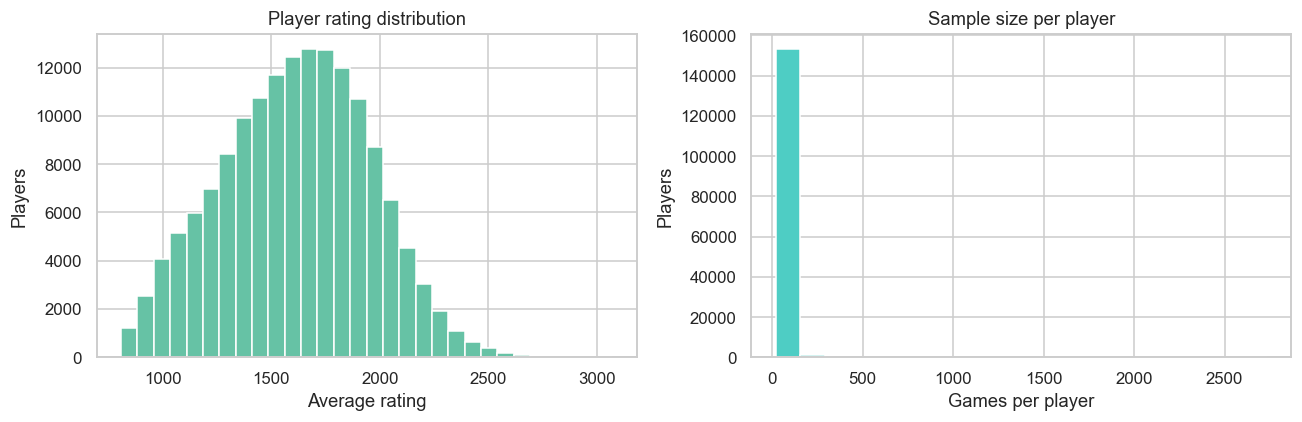

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(features['avg_rating'], bins=30, edgecolor='white')
ax.set(xlabel='Average rating', ylabel='Players', title='Player rating distribution')

ax = axes[1]
ax.hist(features['n_games'], bins=20, edgecolor='white', color='#4ECDC4')
ax.set(xlabel='Games per player', ylabel='Players', title='Sample size per player')

fig.tight_layout()
fig.savefig(FIG_DIR / '01_dataset_overview.png', bbox_inches='tight')
plt.show()


## 2. Feature distributions

Each player is represented by 13 features. Two design choices:

- **Skill adjustment** via Elo expected score — `score_residual` is actual score minus what Elo predicts given opponent ratings. A `+0.05` means the player over-performs their rating by 5 score points per game on average. Orthogonal to raw strength.
- **Opening family proportions** built from ECO code prefixes (`B`/`C` = 1.e4 systems, `D`/`E` = 1.d4). No PGN parsing needed.

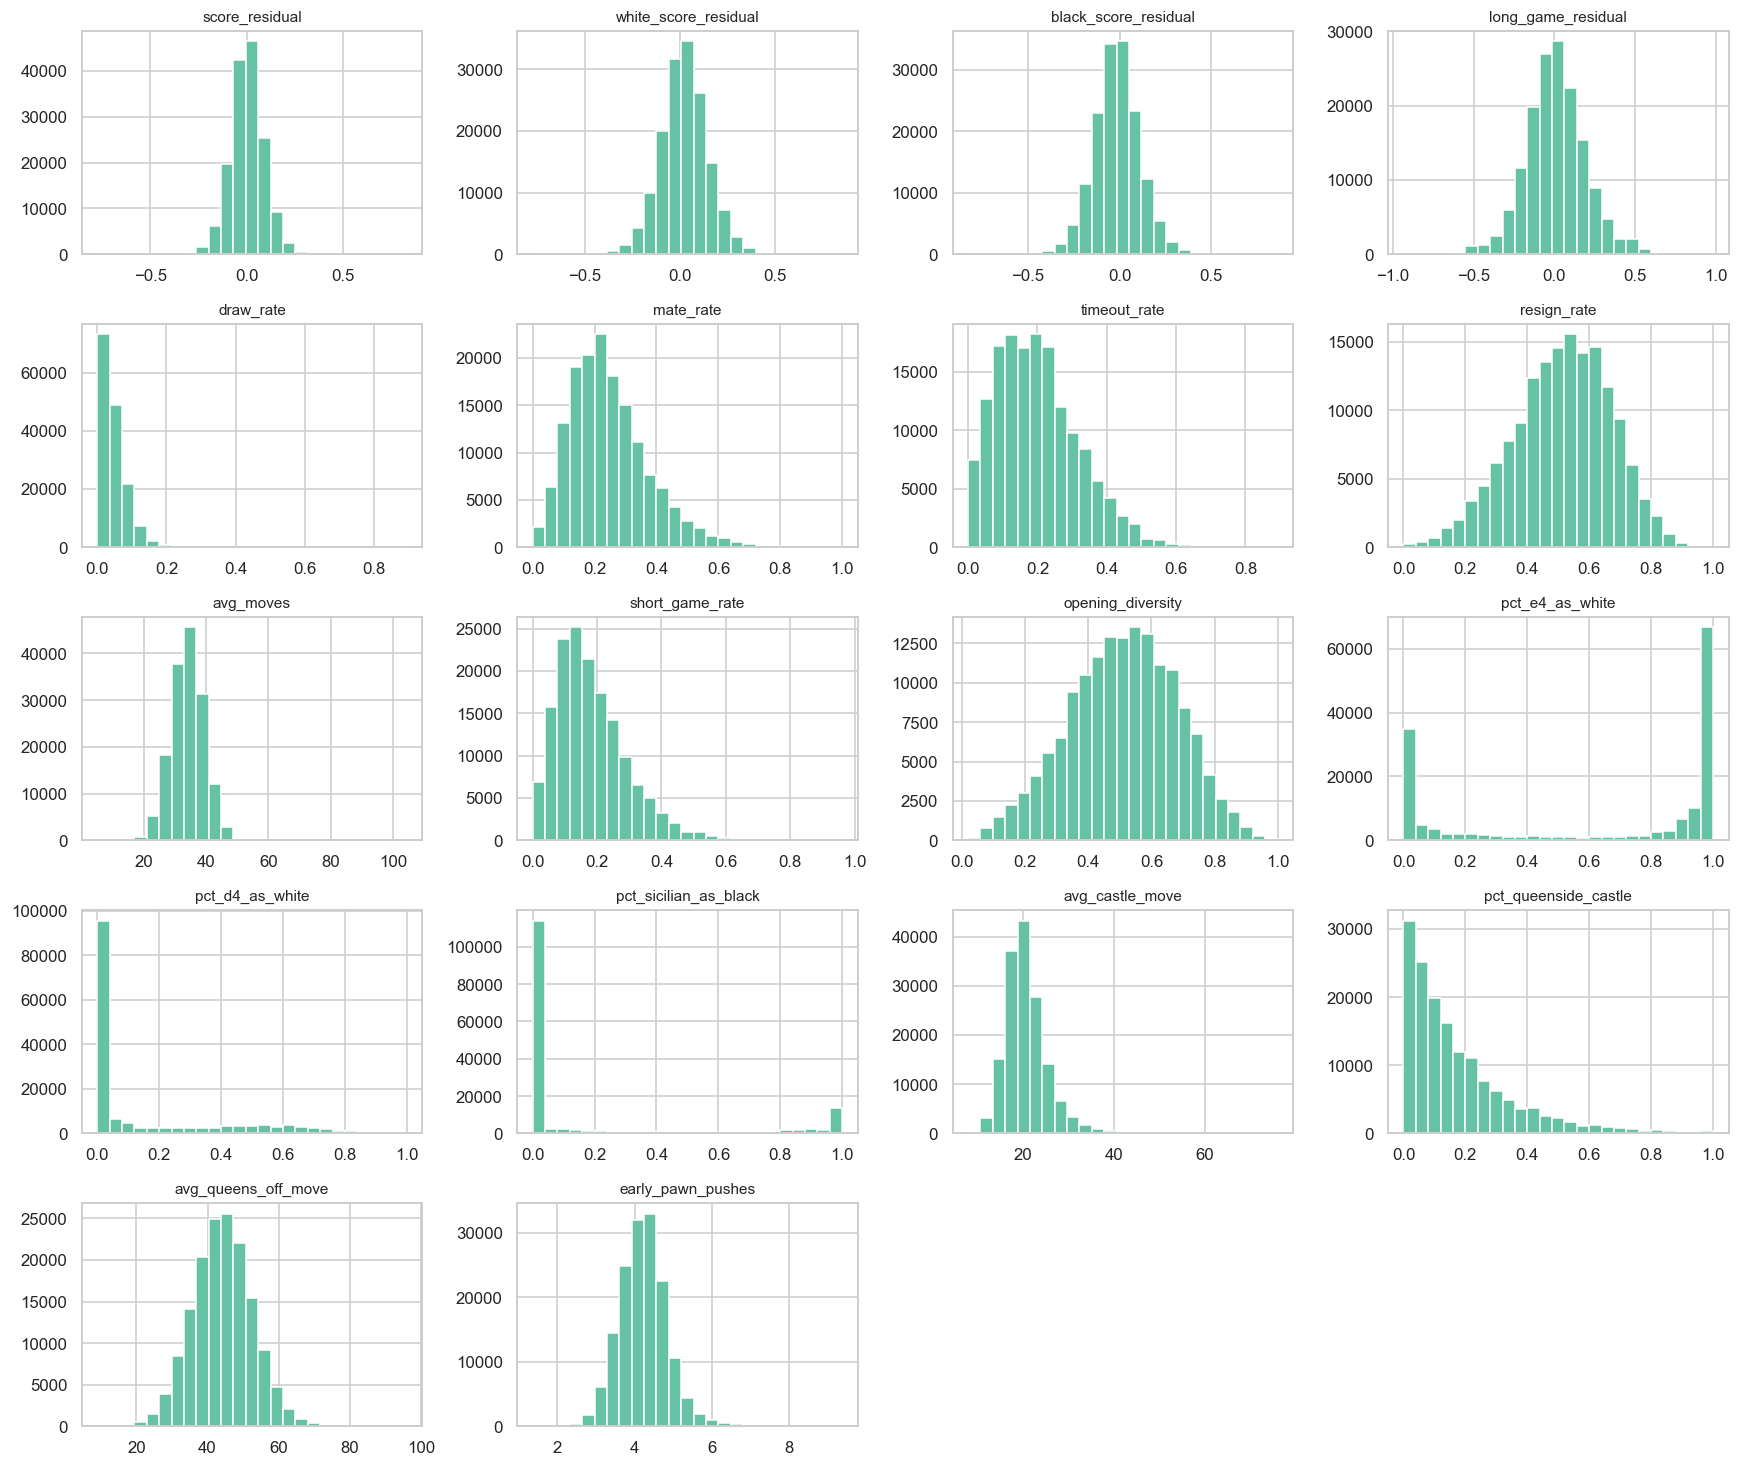

In [4]:
n_cols = 4
n_rows = int(np.ceil(len(FEATURE_COLUMNS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 2.7*n_rows))

for ax, col in zip(axes.flat, FEATURE_COLUMNS):
    ax.hist(features[col], bins=25, edgecolor='white')
    ax.set_title(col, fontsize=10)
for ax in axes.flat[len(FEATURE_COLUMNS):]:
    ax.set_visible(False)

fig.tight_layout()
fig.savefig(FIG_DIR / '02_feature_distributions.png', bbox_inches='tight')
plt.show()


## 3. Feature correlations

Heavily correlated features add redundancy without information. Anything > 0.8 in absolute value is worth flagging.

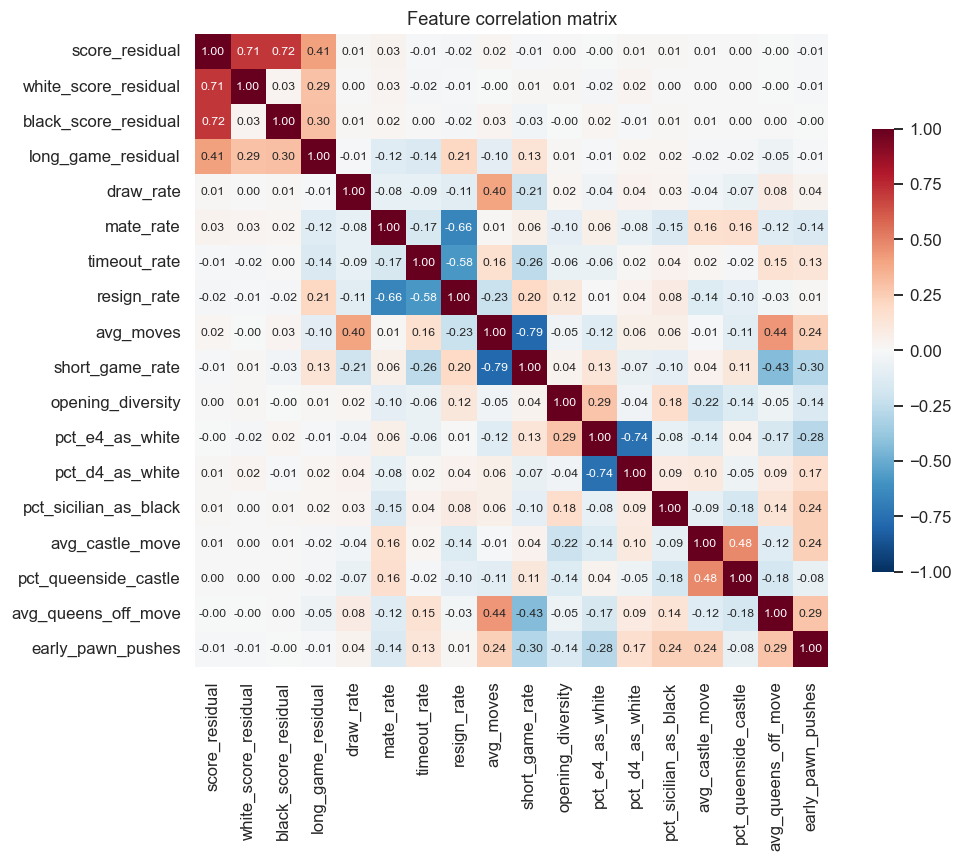

In [5]:
features_pd = features.select(FEATURE_COLUMNS).to_pandas()
corr = features_pd.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=ax, annot_kws={'fontsize': 8}, square=True, cbar_kws={'shrink': 0.7})
ax.set_title('Feature correlation matrix')
fig.tight_layout()
fig.savefig(FIG_DIR / '03_correlations.png', bbox_inches='tight')
plt.show()


**Reading the matrix:**

- `score_residual` is highly correlated with `white_score_residual` and `black_score_residual` by construction — they're sub-aggregates of the same quantity. Carrying all three lets the model give different weight to White vs Black performance.
- `pct_e4_as_white` and `pct_d4_as_white` are strongly negative (≈ -1) — a player who plays 1.e4 80% of the time can only play 1.d4 at most 20%. This is the kind of perfect anti-correlation that suggests we could drop one feature, but keeping both makes downstream interpretation cleaner.
- `resign_rate` and `mate_rate` trade off — losing on resignation excludes losing by checkmate.

## 4. PCA projection

18-dimensional feature space projected to 2D for visualisation. Each point is a player, coloured first by K-Means cluster (left), then by rating (right) — to see whether the clusters are tracking style or just rating.

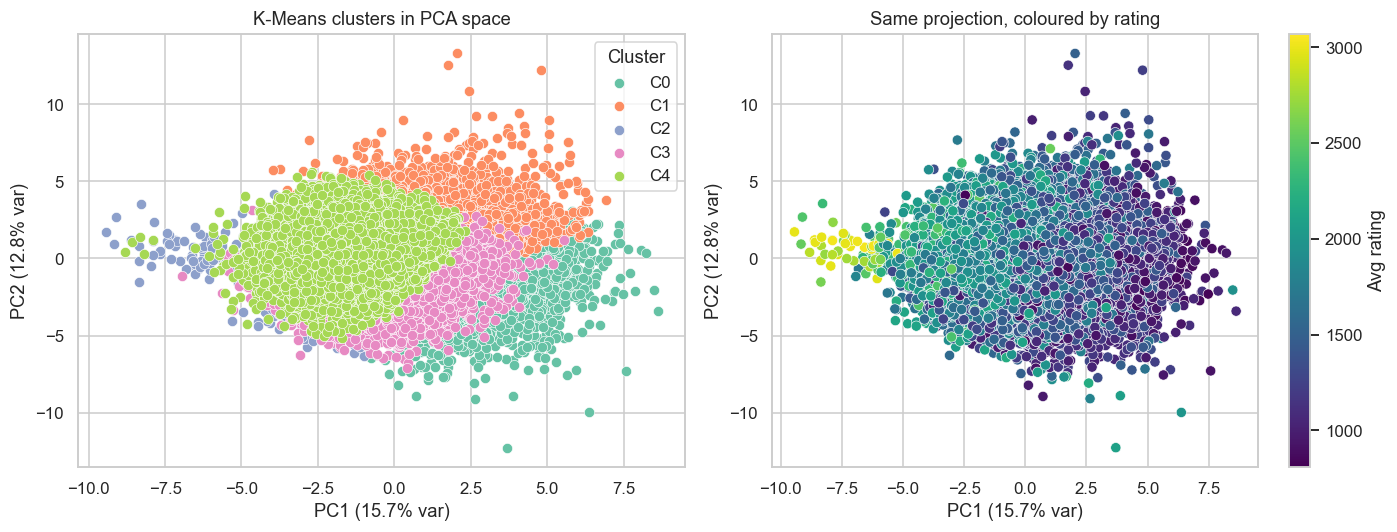

Total variance explained by 2 PCs: 28.5%


In [6]:
X = clustered.select(FEATURE_COLUMNS).to_numpy()
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

clusters_arr = clustered['cluster'].to_numpy()
ratings_arr = clustered['avg_rating'].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for c in sorted(set(clusters_arr.tolist())):
    mask = clusters_arr == c
    ax.scatter(pcs[mask, 0], pcs[mask, 1], s=45, label=f'C{c}', edgecolor='white', linewidth=0.4)
ax.set(xlabel=f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)',
       ylabel=f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)',
       title='K-Means clusters in PCA space')
ax.legend(title='Cluster', loc='best', frameon=True)

ax = axes[1]
sc = ax.scatter(pcs[:, 0], pcs[:, 1], c=ratings_arr, cmap='viridis', s=45, edgecolor='white', linewidth=0.4)
ax.set(xlabel=f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)',
       ylabel=f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)',
       title='Same projection, coloured by rating')
fig.colorbar(sc, ax=ax, label='Avg rating')

fig.tight_layout()
fig.savefig(FIG_DIR / '04_pca.png', bbox_inches='tight')
plt.show()

print(f'Total variance explained by 2 PCs: {pca.explained_variance_ratio_.sum():.1%}')


**Reading the PCA plots:**

If clusters tracked *only* rating, the left and right plots would look identical. The fact that they differ means clusters capture **style on top of rating** — exactly what the skill-adjustment design was meant to surface.

## 5. Cluster characterisation

Heatmap of cluster-mean values for each feature, z-scored *across clusters* so each row highlights what makes that feature distinctive between clusters.

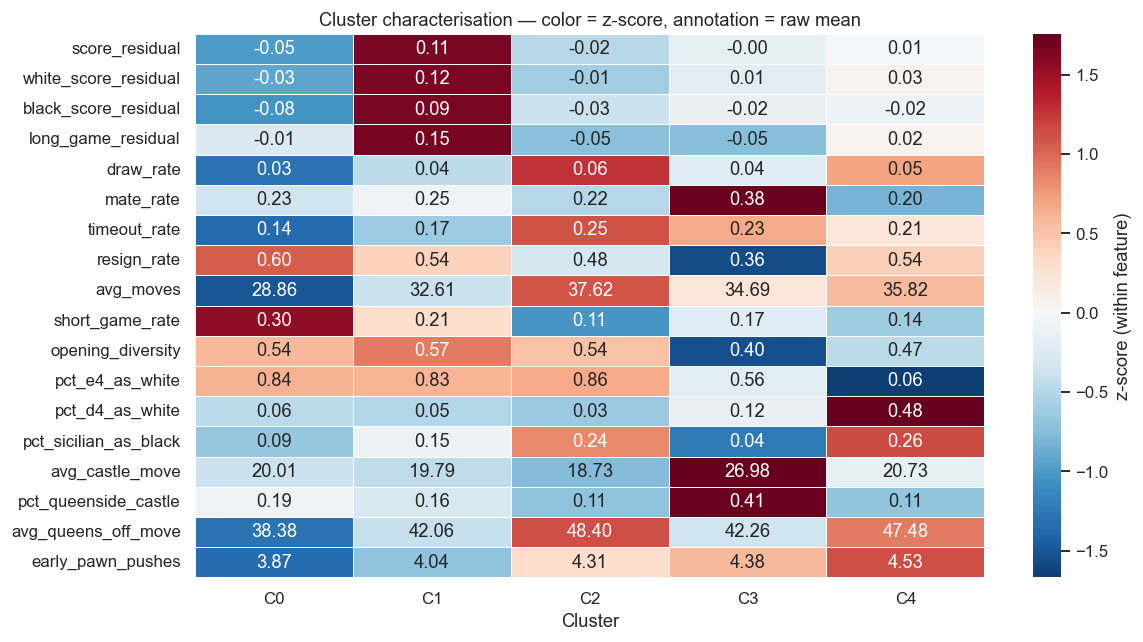

In [7]:
cluster_means = clustered.group_by('cluster').agg([pl.col(c).mean() for c in FEATURE_COLUMNS]).sort('cluster')
cm_df = cluster_means.select(FEATURE_COLUMNS).to_pandas()
cm_df.index = [f'C{i}' for i in cluster_means['cluster'].to_list()]

# Z-score across clusters for each feature (per row, after transpose)
cm_z = (cm_df - cm_df.mean()) / cm_df.std()

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(cm_z.T, annot=cm_df.T, fmt='.2f', cmap='RdBu_r', center=0, ax=ax,
            cbar_kws={'label': 'z-score (within feature)'}, linewidths=0.4)
ax.set_title('Cluster characterisation — color = z-score, annotation = raw mean')
ax.set_xlabel('Cluster')
fig.tight_layout()
fig.savefig(FIG_DIR / '05_cluster_means.png', bbox_inches='tight')
plt.show()


## 6. Opening-family preference by cluster

The clearest behavioural signal: how each cluster splits between 1.e4 and 1.d4 as White.

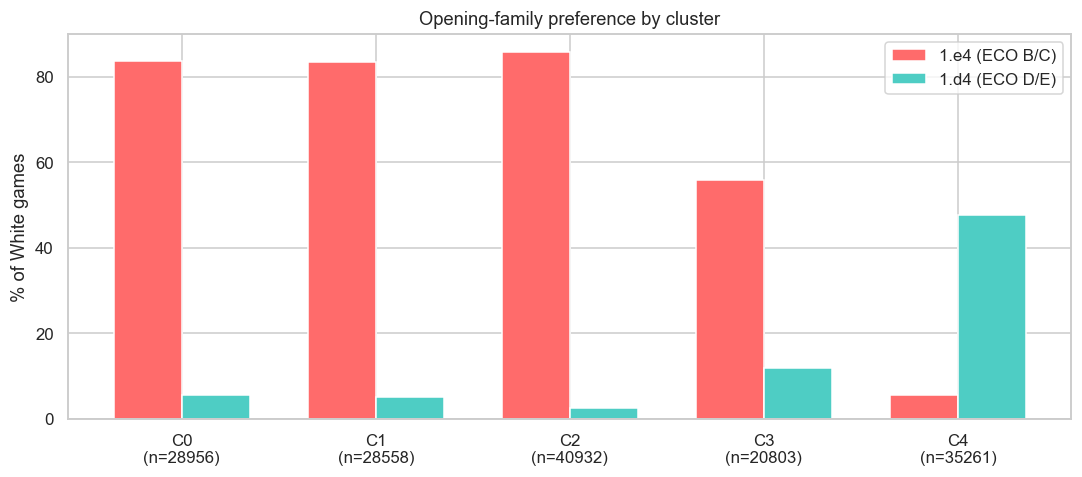

In [8]:
cluster_sizes = clustered.group_by('cluster').len().sort('cluster')
labels = [f'C{i}\n(n={n})' for i, n in zip(cluster_sizes['cluster'], cluster_sizes['len'])]

x = np.arange(len(labels))
width = 0.35
e4 = cm_df['pct_e4_as_white'].values * 100
d4 = cm_df['pct_d4_as_white'].values * 100

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(x - width/2, e4, width, label='1.e4 (ECO B/C)', color='#FF6B6B', edgecolor='white')
ax.bar(x + width/2, d4, width, label='1.d4 (ECO D/E)', color='#4ECDC4', edgecolor='white')
ax.set(xticks=x, xticklabels=labels, ylabel='% of White games',
       title='Opening-family preference by cluster')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / '06_openings_by_cluster.png', bbox_inches='tight')
plt.show()


## Cluster identities

Reading the heatmap above and the opening bar chart (K=5 on 154,510 players):

| Cluster | Avg rating | Identity |
| --- | --- | --- |
| **0** | ~1431 | Quick 1.e4 amateur — 84% e4, decides games fast (~29 moves) |
| **1** | ~1540 | Underrated 1.e4 overperformer — score residual +0.11, +0.15 in long games |
| **2** | ~1789 | 1.e4 grinder — higher-rated, longest games (~38 moves) |
| **3** | ~1415 | Queenside king-hunter — 41% O-O-O, castles late, 38% mate rate |
| **4** | ~1740 | 1.d4 specialist — only 6% e4 vs 48% d4 |

Each identity emerges from a *combination* of features. The Queenside king-hunter (C3) only became visible once castle-side and castle-timing features entered the vector — outcome features alone couldn't see it.

## Phase 3 — does accuracy carry style signal beyond rating?

~12% of Lichess games carry `[%eval]` computer-analysis annotations. We parse them into per-player **ACPL** (average centipawn loss) and **blunder rate** — kept as metadata, not clustering features. The question: do the clusters differ in accuracy *independently of rating*?

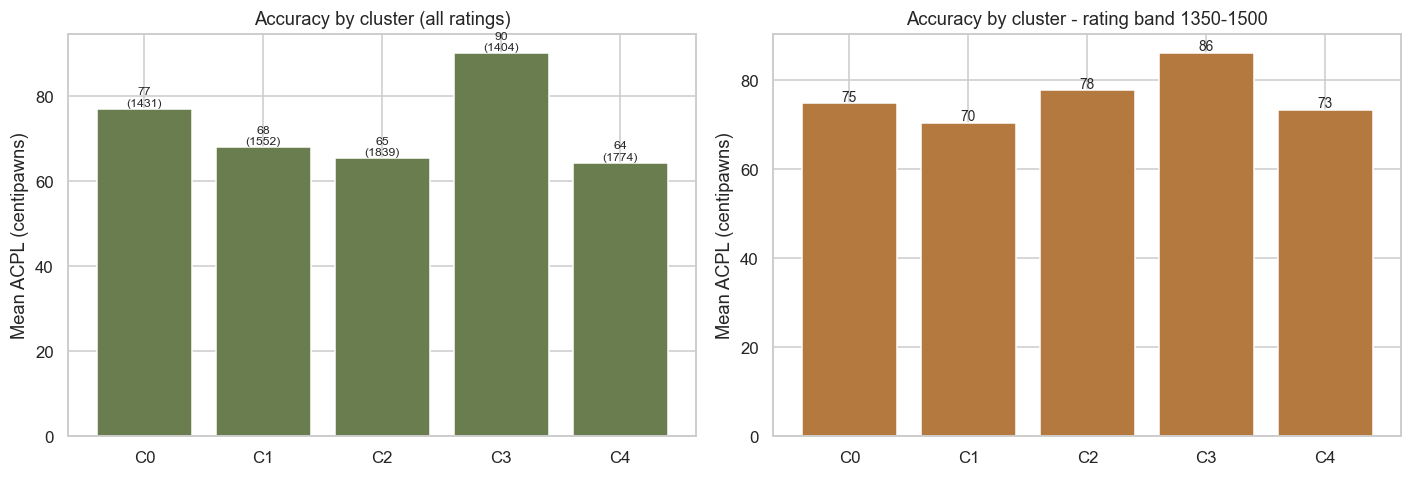

ACPL-rating correlation: -0.549


In [9]:
analyzed = clustered.filter(pl.col('n_analyzed_games') >= 3)

overall = (analyzed.group_by('cluster')
           .agg(acpl=pl.col('acpl').mean(), rating=pl.col('avg_rating').mean(), n=pl.len())
           .sort('cluster').to_pandas())

band = analyzed.filter((pl.col('avg_rating') >= 1350) & (pl.col('avg_rating') <= 1500))
banded = (band.group_by('cluster')
          .agg(acpl=pl.col('acpl').mean(), n=pl.len())
          .sort('cluster').to_pandas())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.bar([f'C{c}' for c in overall['cluster']], overall['acpl'], color='#6a7d4f', edgecolor='white')
ax.set(ylabel='Mean ACPL (centipawns)', title='Accuracy by cluster (all ratings)')
for i, (a, r) in enumerate(zip(overall['acpl'], overall['rating'])):
    ax.text(i, a + 0.5, f'{a:.0f}\n({r:.0f})', ha='center', fontsize=8)

ax = axes[1]
ax.bar([f'C{c}' for c in banded['cluster']], banded['acpl'], color='#b3793f', edgecolor='white')
ax.set(ylabel='Mean ACPL (centipawns)', title='Accuracy by cluster - rating band 1350-1500')
for i, a in enumerate(banded['acpl']):
    ax.text(i, a + 0.5, f'{a:.0f}', ha='center', fontsize=9)

fig.tight_layout()
fig.savefig(FIG_DIR / '07_acpl_by_cluster.png', bbox_inches='tight')
plt.show()

corr = analyzed.select(pl.corr('acpl', 'avg_rating')).item()
print(f'ACPL-rating correlation: {corr:.3f}')


**Reading the two panels.** Left: ACPL drops as rating rises (global ACPL-rating correlation ~ -0.55 — accuracy *is* a large part of strength). Right: holding rating fixed (~1428), the clusters **still** differ by ~16 cp/move. The Queenside king-hunter is the least accurate at any given rating — it trades precision for attacking chances — while the Underrated overperformer is the most accurate, consistent with its +0.11 score residual. Accuracy was never an input to the clustering, yet it separates the clusters exactly as the identities predict: the strongest evidence that the model captures **style**, not just rating.

## Limitations & next steps

- **Silhouette ~0.08** across 281 → 5k → 154k players and 8 → 18 features. The metric won't move with scale or features — chess playstyle is most likely a continuum, not a discrete partition. K-Means imposes hard borders on a smooth cloud. A Gaussian-mixture model or continuous embedding would likely fit better.
- **`pct_e4_as_white` ↔ `pct_d4_as_white` correlation near -1** — could drop one feature without information loss; kept for interpretability.
- **Accuracy can't be a live feature** — the recommender fetches a user's games from the REST API, which has no evals. ACPL stays a characterisation overlay.
- **Single-month training window** — Phase 4 (12 months of dumps) would smooth seasonal/meta shifts.